#  Production-Grade Corrective RAG (CRAG) for Medical QA
> **LangGraph + Gemini + ChromaDB + Sentence Transformers + LangSmith Tracing**

---
## Architecture Overview
```
Query → RETRIEVE → GRADE DOCS → [RELEVANT?]
                                    ├─ ALL RELEVANT  → GENERATE → HALLUCINATION CHECK → Answer
                                    ├─ SOME IRRELEVANT → TRANSFORM QUERY → RE-RETRIEVE → GRADE → GENERATE
                                    └─ ALL IRRELEVANT → WEB SEARCH FALLBACK → GENERATE
```

##  Section 1: Environment Setup & Imports

In [ ]:
import os
import json
import re
import uuid
import warnings
import numpy as np
import pandas as pd
from typing import List, Dict, Any, Optional, Tuple, Literal
from dataclasses import dataclass, field
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# ─── Load .env FIRST ─────────────────────────────────────────────────────────
from dotenv import load_dotenv
_env_path = Path('..') / '.env'
load_dotenv(dotenv_path=_env_path, override=True)
print(f'✅ .env loaded from: {_env_path.resolve()}')

# LangChain core
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.runnables import RunnablePassthrough

# LangChain integrations  ← Groq replaces Gemini
from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader, PyPDFDirectoryLoader
from langchain_chroma import Chroma
from langchain_community.tools.tavily_search import TavilySearchResults

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.graph.state import CompiledStateGraph as CompiledGraph

# Typing for state
from typing_extensions import TypedDict

# Sklearn for cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# LangSmith tracing
from langsmith import Client as LangSmithClient, traceable

print('✅ All imports successful')

✅ .env loaded from: D:\Mini-Project\Gen AI\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\.env
✅ All imports successful


In [46]:
# ─────────────────────────────────────────────
# CONFIGURATION — reads from .env file
# ─────────────────────────────────────────────
import getpass

# Groq API key (free at console.groq.com)
GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
if not GROQ_API_KEY:
    GROQ_API_KEY = getpass.getpass('Enter Groq API Key (free at console.groq.com): ')
os.environ['GROQ_API_KEY'] = GROQ_API_KEY
print(f'✅ GROQ_API_KEY loaded')

# Tavily (web search fallback)
TAVILY_API_KEY = os.environ.get('TAVILY_API_KEY') or getpass.getpass('Enter Tavily API Key: ')
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY

LANGSMITH_API_KEY = os.environ.get('LANGSMITH_API_KEY', '')
LANGSMITH_PROJECT = os.environ.get('LANGSMITH_PROJECT', 'MedQuery-CRAG')

if LANGSMITH_API_KEY:
    os.environ['LANGCHAIN_TRACING_V2'] = 'true'
    os.environ['LANGCHAIN_API_KEY']     = LANGSMITH_API_KEY
    os.environ['LANGCHAIN_PROJECT']     = LANGSMITH_PROJECT
    os.environ['LANGCHAIN_ENDPOINT']    = os.environ.get('LANGSMITH_ENDPOINT', 'https://api.smith.langchain.com')
    print(f' LangSmith tracing ENABLED → project: "{LANGSMITH_PROJECT}"')
    try:
        ls_client = LangSmithClient(api_key=LANGSMITH_API_KEY)
        print(f'   LangSmith client connected ✓')
    except Exception as e:
        print(f'   LangSmith client error: {e}')
else:
    os.environ['LANGCHAIN_TRACING_V2'] = 'false'
    print('  LangSmith tracing DISABLED')

# ─────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────
PROJECT_ROOT       = Path('..').resolve()
DATA_DIR           = PROJECT_ROOT / 'data'
CHROMA_PERSIST_DIR = str(PROJECT_ROOT / 'chroma_medical_db')
COLLECTION_NAME    = 'medical_documents'

CHUNK_SIZE    = 500
CHUNK_OVERLAP = 50
RETRIEVAL_K   = 5

print(f'✅ Configuration loaded')
print(f'   Data dir  : {DATA_DIR}')
print(f'   ChromaDB  : {CHROMA_PERSIST_DIR}')

✅ GROQ_API_KEY loaded
 LangSmith tracing ENABLED → project: "MedQuery-CRAG"
   LangSmith client connected ✓
✅ Configuration loaded
   Data dir  : D:\Mini-Project\Gen AI\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\data
   ChromaDB  : D:\Mini-Project\Gen AI\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\chroma_medical_db


## Section 2: Data Ingestion 

In [9]:
# ─────────────────────────────────────────────────────────────────────
# LOAD ALL PDFs USING PyPDFDirectoryLoader
# Automatically finds and loads: Harrison's.pdf, Medical_book.pdf, Oxford.pdf
# Returns one Document per page across all PDFs.
# ─────────────────────────────────────────────────────────────────────

if not DATA_DIR.exists() or not list(DATA_DIR.glob('*.pdf')):
    raise FileNotFoundError(f'No PDFs found in: {DATA_DIR}')

print(f'Loading all PDFs from: {DATA_DIR}...')
loader    = PyPDFDirectoryLoader(str(DATA_DIR))
raw_pages = loader.load()   # List[Document]

# Annotate each page with clean source metadata
for page_doc in raw_pages:
    source_path = Path(page_doc.metadata.get('source', ''))
    stem        = source_path.stem
    page_doc.metadata.setdefault('category', 'medical_reference')
    page_doc.metadata['book']    = stem        # e.g. "Harrison's", "Oxford"
    page_doc.metadata['title']   = f"{stem} — p{page_doc.metadata.get('page', '?')}"
    page_doc.metadata['doc_id']  = str(uuid.uuid4())

# Summary per book
from collections import Counter
book_counts = Counter(d.metadata['book'] for d in raw_pages)

print(f'\n✅ Total pages loaded: {len(raw_pages)}')
print(f'\n📖 Pages per book:')
for book, count in sorted(book_counts.items()):
    print(f'   • {book}: {count} pages')

print(f'\nSample page metadata: {raw_pages[0].metadata}')
print(f'Sample content (first 300 chars):\n{raw_pages[0].page_content[:300]}')


Loading all PDFs from: D:\Mini-Project\Gen AI\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\data...

✅ Total pages loaded: 6661

📖 Pages per book:
   • Harrison's: 5113 pages
   • Medical_book: 637 pages
   • Oxford: 911 pages

Sample page metadata: {'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2009-08-20T02:28:03-05:00', 'author': 'EDGE Note', 'moddate': '2009-08-20T02:28:03-05:00', 'title': "Harrison's — p0", 'source': "D:\\Mini-Project\\Gen AI\\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\\data\\Harrison's.pdf", 'total_pages': 5113, 'page': 0, 'page_label': '1', 'category': 'medical_reference', 'book': "Harrison's", 'doc_id': '4af178f0-ff7e-4810-b339-3c115284b0e2'}
Sample content (first 300 chars):
About this release
FRONT MATTER
PART ONE - INTRODUCTION TO CLINICAL MEDICINE
PART TWO - CARDINAL MANIFESTATIONS AND PRESENTATION OF DISEASE
PART THREE - GENETICS AND DISEASE
PART FOUR - CLINICAL PHARMACOLOGY
PART FIVE 

In [10]:
def chunk_documents(docs: List[Document], chunk_size: int = 500, chunk_overlap: int = 50) -> List[Document]:
    """
    Split documents into chunks using RecursiveCharacterTextSplitter.

    Args:
        docs: List of LangChain Documents
        chunk_size: Maximum characters per chunk
        chunk_overlap: Overlap between consecutive chunks
    Returns:
        List of chunked Document objects
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=['\n\n', '\n', '. ', ' ', ''],
        length_function=len
    )
    chunks = splitter.split_documents(docs)
    # Preserve and annotate metadata
    for i, chunk in enumerate(chunks):
        chunk.metadata['chunk_id']     = i
        chunk.metadata['chunk_length'] = len(chunk.page_content)
    return chunks


chunked_docs = chunk_documents(raw_pages, CHUNK_SIZE, CHUNK_OVERLAP)

print(f'✅ Raw pages   : {len(raw_pages)}')
print(f'✅ Total chunks: {len(chunked_docs)}')
print(f'\nSample chunk:\n{"-"*50}')
print(chunked_docs[0].page_content[:300])
print(f'Metadata: {chunked_docs[0].metadata}')

✅ Raw pages   : 6661
✅ Total chunks: 52181

Sample chunk:
--------------------------------------------------
About this release
FRONT MATTER
PART ONE - INTRODUCTION TO CLINICAL MEDICINE
PART TWO - CARDINAL MANIFESTATIONS AND PRESENTATION OF DISEASE
PART THREE - GENETICS AND DISEASE
PART FOUR - CLINICAL PHARMACOLOGY
PART FIVE - NUTRITION
PART SIX - ONCOLOGY AND HEMATOLOGY
PART SEVEN - INFECTIOUS DISEASES
PA
Metadata: {'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2009-08-20T02:28:03-05:00', 'author': 'EDGE Note', 'moddate': '2009-08-20T02:28:03-05:00', 'title': "Harrison's — p0", 'source': "D:\\Mini-Project\\Gen AI\\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\\data\\Harrison's.pdf", 'total_pages': 5113, 'page': 0, 'page_label': '1', 'category': 'medical_reference', 'book': "Harrison's", 'doc_id': '4af178f0-ff7e-4810-b339-3c115284b0e2', 'chunk_id': 0, 'chunk_length': 450}


## Section 3: ChromaDB Vector Store Setup & Indexing

In [11]:
# Initialize Sentence Transformer embeddings
print('Loading sentence transformer model...')
embedding_model = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}  # Normalize for cosine similarity
)
print('✅ Embedding model loaded: all-MiniLM-L6-v2')

# Test embedding
test_emb = embedding_model.embed_query('test medical query')
print(f'✅ Embedding dimensions: {len(test_emb)}')

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6027.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded: all-MiniLM-L6-v2
✅ Embedding dimensions: 384


In [12]:
def build_vector_store(chunks: List[Document], persist_dir: str, collection: str) -> Chroma:
    """
    Build and persist ChromaDB vector store from document chunks.
    Clears existing collection to ensure fresh indexing.

    Args:
        chunks: List of chunked Documents
        persist_dir: Local directory for ChromaDB persistence
        collection: ChromaDB collection name
    Returns:
        Chroma vector store instance
    """
    import shutil
    # Clear old DB for clean build
    if Path(persist_dir).exists():
        shutil.rmtree(persist_dir)
        print(f'  Cleared existing ChromaDB at {persist_dir}')

    print(f'  Indexing {len(chunks)} chunks... (this may take a few minutes for large PDFs)')
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        persist_directory=persist_dir,
        collection_name=collection
    )
    print(f'✅ ChromaDB built with {vectorstore._collection.count()} embeddings')
    return vectorstore


vectorstore = build_vector_store(chunked_docs, CHROMA_PERSIST_DIR, COLLECTION_NAME)
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': RETRIEVAL_K}
)

# Verify retrieval — use .invoke() (get_relevant_documents is deprecated)
test_query   = 'What is the maximum daily dose of metformin?'
test_results = retriever.invoke(test_query)
print(f'\n✅ Test retrieval for: "{test_query}"')
for i, doc in enumerate(test_results[:2]):
    print(f'  [{i+1}] {doc.metadata.get("title", "Doc")} — {doc.page_content[:100]}...')

  Cleared existing ChromaDB at D:\Mini-Project\Gen AI\MedQuery-AI-Corrective-RAG-System-for-Clinical-QA\chroma_medical_db
  Indexing 52181 chunks... (this may take a few minutes for large PDFs)
✅ ChromaDB built with 52181 embeddings

✅ Test retrieval for: "What is the maximum daily dose of metformin?"
  [1] Harrison's — p4181 — glucose utilization slightly (Table 333-12). Metformin reduces fasting plasma glucose 
and insulin l...
  [2] Harrison's — p4656 — by 0.75 mg at weekly intervals depending on need and tolerance. The usual 
maintenance dose is 0.5 t...


##  Section 4: LangGraph CRAG Pipeline Implementation

In [47]:
# ─────────────────────────────────────────────────────────────────────
# Initialize Groq LLM (Free, fast — replaces Gemini)
# Free tier: 14,400 req/day | Model: llama-3.1-8b-instant
# ─────────────────────────────────────────────────────────────────────
llm = ChatGroq(
    model="llama-3.1-8b-instant",   # Fast + great JSON output
    temperature=0.1,                 # Low temp for factual medical QA
    max_tokens=1024,
    groq_api_key=GROQ_API_KEY
)

# Tavily web search (fallback — unchanged)
web_search_tool = TavilySearchResults(
    max_results=3,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=False
)

print('✅ Groq LLM initialized (llama-3.1-8b-instant)')
print('✅ Tavily web search initialized')


✅ Groq LLM initialized (llama-3.1-8b-instant)
✅ Tavily web search initialized


In [48]:
# Quick connectivity test — should return a short answer
test_resp = llm.invoke("What is the capital of France? Answer in one word.")
print(f"✅ Model responding: {test_resp.content}")

✅ Model responding: Paris.


In [49]:
# ─────────────────────────────────────────────────────────────────────
# LANGGRAPH STATE DEFINITION
# ─────────────────────────────────────────────────────────────────────
class CRAGState(TypedDict):
    """State passed between nodes in the CRAG LangGraph pipeline."""
    # Input
    question: str
    # Retrieved documents
    documents: List[Document]
    # Graded documents with relevance labels
    graded_documents: List[Dict[str, Any]]
    # Routing decision
    route_decision: str  # 'generate' | 'transform' | 'web_search'
    # Transformed query (if applicable)
    transformed_query: Optional[str]
    # Web search results (if applicable)
    web_results: Optional[List[Dict]]
    # Generated answer
    generation: str
    # Hallucination check result
    hallucination_check: str  # 'grounded' | 'not_grounded'
    # Number of retries (prevent infinite loops)
    retry_count: int
    # Source citations
    sources: List[str]
    # Pipeline path taken (for observability)
    pipeline_path: List[str]

In [50]:
# ─────────────────────────────────────────────────────────────────────
# NODE 1: RETRIEVE
# @traceable wraps each node so every invocation appears in LangSmith
# ─────────────────────────────────────────────────────────────────────
@traceable(name='CRAG-Retrieve', run_type='retriever')
def retrieve_node(state: CRAGState) -> CRAGState:
    """
    Performs k-NN similarity search against ChromaDB.
    Uses the current question (or transformed query if available).
    """
    query = state.get('transformed_query') or state['question']
    print(f'\n[RETRIEVE] Query: {query[:80]}...' if len(query) > 80 else f'\n[RETRIEVE] Query: {query}')

    # Use .invoke() — get_relevant_documents() is deprecated in LangChain >=0.2
    docs = retriever.invoke(query)

    path = state.get('pipeline_path', []) + ['RETRIEVE']
    print(f'  → Retrieved {len(docs)} documents')

    return {
        **state,
        'documents': docs,
        'pipeline_path': path
    }


# ─────────────────────────────────────────────────────────────────────
# NODE 2: GRADE DOCUMENTS
# ─────────────────────────────────────────────────────────────────────
GRADE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', """
You are a medical information relevance grader.
Given a clinical question and a retrieved document chunk, assess whether
the document contains information that would help answer the question.

Respond ONLY with a JSON object:
{{
  "relevance": "RELEVANT" | "IRRELEVANT" | "AMBIGUOUS",
  "reason": "<brief one-line reason>"
}}

Rules:
- RELEVANT: Document directly addresses the question (dosage, mechanism, diagnosis, protocol)
- IRRELEVANT: Document has no useful overlap with the question
- AMBIGUOUS: Document partially overlaps or contains tangential information
"""),
    ('human', 'Clinical Question: {question}\n\nDocument:\n{document}')
])

grade_chain = GRADE_PROMPT | llm | StrOutputParser()


@traceable(name='CRAG-GradeDocuments', run_type='chain')
def grade_documents_node(state: CRAGState) -> CRAGState:
    """
    LLM grades each retrieved document as RELEVANT / IRRELEVANT / AMBIGUOUS.
    Filters and labels documents for routing decision.
    """
    print('\n[GRADE DOCUMENTS]')
    question  = state['question']
    documents = state['documents']

    graded = []
    for i, doc in enumerate(documents):
        try:
            result = grade_chain.invoke({
                'question': question,
                'document': doc.page_content[:600]  # Truncate to save tokens
            })
            # Parse JSON from response (handle potential markdown wrapping)
            result_clean = result.strip().replace('```json', '').replace('```', '').strip()
            grade_data = json.loads(result_clean)
            relevance  = grade_data.get('relevance', 'AMBIGUOUS')
        except Exception as e:
            # Default to AMBIGUOUS on parse failure
            relevance  = 'AMBIGUOUS'
            grade_data = {'relevance': 'AMBIGUOUS', 'reason': str(e)[:50]}

        graded.append({
            'document':   doc,
            'relevance':  relevance,
            'reason':     grade_data.get('reason', ''),
            'title':      doc.metadata.get('title', 'Unknown')
        })
        print(f'  [{i+1}] {doc.metadata.get("title", "Doc")[:40]} → {relevance}')

    path = state.get('pipeline_path', []) + ['GRADE_DOCUMENTS']
    return {
        **state,
        'graded_documents': graded,
        'pipeline_path': path
    }


# ─────────────────────────────────────────────────────────────────────
# NODE 3: ROUTE (conditional edges)
# ─────────────────────────────────────────────────────────────────────
@traceable(name='CRAG-RouteDocuments', run_type='chain')
def route_documents(state: CRAGState) -> str:
    """
    Routing function for conditional edges in LangGraph.

    Rules:
    - All RELEVANT → 'generate'
    - Some IRRELEVANT/AMBIGUOUS → 'transform_query'
    - All IRRELEVANT/AMBIGUOUS → 'web_search'
    - Max 2 retries to prevent infinite loops
    """
    graded       = state.get('graded_documents', [])
    retry_count  = state.get('retry_count', 0)

    relevant_count   = sum(1 for g in graded if g['relevance'] == 'RELEVANT')
    irrelevant_count = sum(1 for g in graded if g['relevance'] == 'IRRELEVANT')
    total            = len(graded)

    print(f'\n[ROUTE] Relevant: {relevant_count}/{total} | Retry: {retry_count}')

    # Prevent infinite loops
    if retry_count >= 2:
        print('  → Max retries reached → generate (best effort)')
        return 'generate'

    if relevant_count == total:          # All relevant
        print('  → All relevant → generate')
        return 'generate'
    elif irrelevant_count == total:      # All irrelevant
        print('  → All irrelevant → web_search')
        return 'web_search'
    else:                                # Mixed
        print('  → Mixed relevance → transform_query')
        return 'transform_query'


# ─────────────────────────────────────────────────────────────────────
# NODE 4: TRANSFORM QUERY
# ─────────────────────────────────────────────────────────────────────
TRANSFORM_PROMPT = ChatPromptTemplate.from_messages([
    ('system', """
You are a medical query optimization specialist.
Rewrite the given clinical question to improve retrieval from a medical knowledge base.
The rewritten query should:
1. Include relevant medical terminology (ICD codes, drug generic names, clinical acronyms)
2. Be more specific and precise
3. Expand abbreviations
4. Focus on the core clinical concept
Respond with ONLY the rewritten query, no explanation.
"""),
    ('human', 'Original query: {question}\nRewritten query:')
])

transform_chain = TRANSFORM_PROMPT | llm | StrOutputParser()


@traceable(name='CRAG-TransformQuery', run_type='chain')
def transform_query_node(state: CRAGState) -> CRAGState:
    """
    Rewrites the query using medical terminology for improved retrieval.
    Increments retry_count to prevent infinite loops.
    """
    print('\n[TRANSFORM QUERY]')
    original    = state['question']
    transformed = transform_chain.invoke({'question': original}).strip()
    print(f'  Original:    {original}')
    print(f'  Transformed: {transformed}')

    path = state.get('pipeline_path', []) + ['TRANSFORM_QUERY']
    return {
        **state,
        'transformed_query': transformed,
        'retry_count':       state.get('retry_count', 0) + 1,
        'pipeline_path':     path
    }


# ─────────────────────────────────────────────────────────────────────
# NODE 5: WEB SEARCH FALLBACK
# ─────────────────────────────────────────────────────────────────────
@traceable(name='CRAG-WebSearch', run_type='tool')
def web_search_node(state: CRAGState) -> CRAGState:
    """
    Fallback web search using Tavily API when all retrieved docs are irrelevant.
    Converts search results into Document objects for uniform downstream processing.
    """
    print('\n[WEB SEARCH FALLBACK]')
    query = state.get('transformed_query') or state['question']

    try:
        results  = web_search_tool.invoke({'query': f'medical {query}'})
        web_docs = []
        for r in results:
            if isinstance(r, dict):
                web_docs.append(Document(
                    page_content=r.get('content', r.get('snippet', '')),
                    metadata={
                        'title':    r.get('title', 'Web Result'),
                        'source':   r.get('url', 'web'),
                        'category': 'web_search'
                    }
                ))

        print(f'  → Found {len(web_docs)} web results')
        path = state.get('pipeline_path', []) + ['WEB_SEARCH']
        return {
            **state,
            'documents':     web_docs,
            'web_results':   results,
            'pipeline_path': path
        }
    except Exception as e:
        print(f'  ⚠️  Web search failed: {e}. Using original documents.')
        path = state.get('pipeline_path', []) + ['WEB_SEARCH_FAILED']
        return {**state, 'pipeline_path': path}


# ─────────────────────────────────────────────────────────────────────
# NODE 6: GENERATE
# ─────────────────────────────────────────────────────────────────────
GENERATE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', """
You are an expert medical AI assistant helping clinicians with evidence-based answers.
Answer the clinical question using ONLY the provided context documents.

RULES:
1. Base your answer strictly on the provided context — do not introduce external knowledge
2. Be precise and clinically accurate
3. Include specific values (dosages, thresholds, timeframes) from the context
4. If context is insufficient, clearly state what information is missing
5. End with: SOURCES: [list the document titles used]

Format: Clinical Answer → Sources
"""),
    ('human', """
Clinical Question: {question}

Context Documents:
{context}

Provide a concise, clinically actionable answer with source citations.
""")
])

generate_chain = GENERATE_PROMPT | llm | StrOutputParser()


@traceable(name='CRAG-Generate', run_type='llm')
def generate_node(state: CRAGState) -> CRAGState:
    """
    Generates grounded answer using Gemini LLM with relevant context.
    Uses only RELEVANT and AMBIGUOUS graded documents (filters IRRELEVANT).
    """
    print('\n[GENERATE]')
    question   = state['question']
    graded_docs = state.get('graded_documents', [])
    all_docs   = state.get('documents', [])

    # Use relevant+ambiguous graded docs; fall back to all docs if grading absent
    if graded_docs:
        context_docs = [g['document'] for g in graded_docs
                       if g['relevance'] in ('RELEVANT', 'AMBIGUOUS')]
        if not context_docs:
            context_docs = [g['document'] for g in graded_docs]  # Use all if none pass filter
    else:
        context_docs = all_docs

    # Format context with titles
    context_str = '\n\n---\n'.join([
        f"[SOURCE: {doc.metadata.get('title', 'Unknown')}]\n{doc.page_content}"
        for doc in context_docs[:5]  # Limit to top 5 for context window
    ])

    generation = generate_chain.invoke({
        'question': question,
        'context':  context_str
    })

    sources = [doc.metadata.get('title', 'Unknown') for doc in context_docs]

    print(f'  → Generated answer ({len(generation)} chars)')
    path = state.get('pipeline_path', []) + ['GENERATE']
    return {
        **state,
        'generation':     generation,
        'sources':        sources,
        'pipeline_path':  path
    }


# ─────────────────────────────────────────────────────────────────────
# NODE 7: HALLUCINATION CHECK
# ─────────────────────────────────────────────────────────────────────
HALLUCINATION_CHECK_PROMPT = ChatPromptTemplate.from_messages([
    ('system', """
You are a medical fact-checking AI verifying answer groundedness.
Given a generated answer and the source context, determine whether every factual
claim in the answer is supported by the provided context.

Respond ONLY with a JSON object:
{{
  "verdict": "grounded" | "not_grounded",
  "ungrounded_claims": ["claim1", "claim2"],
  "confidence": 0.0-1.0,
  "reason": "brief explanation"
}}

Use 'not_grounded' only if specific factual claims (dosages, diagnoses, thresholds)
cannot be verified in the context. Extrapolations and inferences count as grounded.
"""),
    ('human', """
Generated Answer:
{generation}

Source Context:
{context}
""")
])

hallucination_chain = HALLUCINATION_CHECK_PROMPT | llm | StrOutputParser()


@traceable(name='CRAG-HallucinationCheck', run_type='chain')
def hallucination_check_node(state: CRAGState) -> CRAGState:
    """
    Verifies generated answer is grounded in retrieved context.
    Acts as a safety gate before returning to user.
    """
    print('\n[HALLUCINATION CHECK]')
    generation = state['generation']
    docs       = state.get('documents', [])

    context_str = '\n'.join([doc.page_content[:400] for doc in docs[:3]])

    try:
        result = hallucination_chain.invoke({
            'generation': generation[:1500],
            'context':    context_str[:2000]
        })
        result_clean = result.strip().replace('```json', '').replace('```', '').strip()
        check_data   = json.loads(result_clean)
        verdict      = check_data.get('verdict', 'grounded')
        confidence   = check_data.get('confidence', 1.0)
    except Exception as e:
        verdict    = 'grounded'  # Default to grounded on parse failure
        confidence = 0.7
        print(f'  ⚠️  Parse error: {e}')

    print(f'  → Verdict: {verdict} (confidence: {confidence:.2f})')
    path = state.get('pipeline_path', []) + ['HALLUCINATION_CHECK']
    return {
        **state,
        'hallucination_check': verdict,
        'pipeline_path':       path
    }


def should_regenerate(state: CRAGState) -> str:
    """Conditional edge after hallucination check."""
    if state.get('hallucination_check') == 'not_grounded' and state.get('retry_count', 0) < 2:
        print('  → Not grounded → regenerating with web search')
        return 'web_search'
    return 'end'


print('✅ All CRAG nodes defined')

✅ All CRAG nodes defined


✅ CRAG LangGraph pipeline compiled


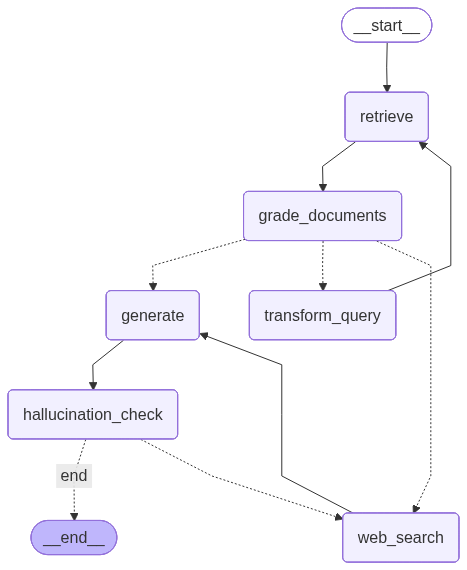

✅ Graph visualization displayed


In [51]:
# ─────────────────────────────────────────────────────────────────────
# BUILD LANGGRAPH PIPELINE
# ─────────────────────────────────────────────────────────────────────
def build_crag_graph() -> CompiledGraph:
    """
    Assembles the full CRAG LangGraph pipeline with:
    - Stateful nodes
    - Conditional routing edges
    - Retry loops with circuit breaker
    """
    graph = StateGraph(CRAGState)

    # -- Add Nodes --
    graph.add_node('retrieve',           retrieve_node)
    graph.add_node('grade_documents',    grade_documents_node)
    graph.add_node('transform_query',    transform_query_node)
    graph.add_node('web_search',         web_search_node)
    graph.add_node('generate',           generate_node)
    graph.add_node('hallucination_check', hallucination_check_node)

    # -- Entry Point --
    graph.set_entry_point('retrieve')

    # -- Static Edges --
    graph.add_edge('retrieve',        'grade_documents')
    graph.add_edge('transform_query', 'retrieve')        # Re-retrieve with better query
    graph.add_edge('web_search',      'generate')        # Web results → generate directly
    graph.add_edge('generate',        'hallucination_check')

    # -- Conditional Edge: Route after grading --
    graph.add_conditional_edges(
        'grade_documents',
        route_documents,
        {
            'generate':        'generate',
            'transform_query': 'transform_query',
            'web_search':      'web_search'
        }
    )

    # -- Conditional Edge: After hallucination check --
    graph.add_conditional_edges(
        'hallucination_check',
        should_regenerate,
        {
            'web_search': 'web_search',
            'end':        END
        }
    )

    return graph.compile()


crag_pipeline = build_crag_graph()
print('✅ CRAG LangGraph pipeline compiled')

# Visualize the graph
try:
    from IPython.display import Image, display
    graph_png = crag_pipeline.get_graph().draw_mermaid_png()
    display(Image(graph_png))
    print('✅ Graph visualization displayed')
except Exception as e:
    print(f'Graph visualization skipped: {e}')
    print('\nMermaid Graph:')
    print(crag_pipeline.get_graph().draw_mermaid())

In [52]:
# ─────────────────────────────────────────────────────────────────────
# CRAG PIPELINE RUNNER
# @traceable here wraps the entire end-to-end run as a single LangSmith trace
# ─────────────────────────────────────────────────────────────────────
@traceable(name='MedQuery-CRAG-Pipeline', run_type='chain')
def run_crag(question: str, verbose: bool = True) -> Dict[str, Any]:
    """
    Run a question through the full CRAG pipeline.

    Args:
        question: Clinical question string
        verbose: Print pipeline trace
    Returns:
        Dict with answer, sources, pipeline_path, hallucination_check
    """
    initial_state: CRAGState = {
        'question':           question,
        'documents':          [],
        'graded_documents':   [],
        'route_decision':     '',
        'transformed_query':  None,
        'web_results':        None,
        'generation':         '',
        'hallucination_check': '',
        'retry_count':        0,
        'sources':            [],
        'pipeline_path':      []
    }

    if verbose:
        print(f'\n{"="*60}')
        print(f'CRAG QUERY: {question}')
        print('='*60)

    final_state = crag_pipeline.invoke(initial_state)

    if verbose:
        print(f'\n{"─"*60}')
        print(f'PIPELINE PATH: {" → ".join(final_state["pipeline_path"])}')
        print(f'HALLUCINATION CHECK: {final_state["hallucination_check"]}')
        print(f'SOURCES: {final_state["sources"]}')
        print(f'\nANSWER:\n{final_state["generation"]}')

    return {
        'question':           question,
        'answer':             final_state['generation'],
        'sources':            final_state['sources'],
        'pipeline_path':      final_state['pipeline_path'],
        'hallucination_check': final_state['hallucination_check'],
        'documents':          final_state['documents'],
        'graded_documents':   final_state.get('graded_documents', [])
    }


# Test the CRAG pipeline
test_result = run_crag('What is the maximum daily dose of metformin and what monitoring is required?')


CRAG QUERY: What is the maximum daily dose of metformin and what monitoring is required?

[RETRIEVE] Query: What is the maximum daily dose of metformin and what monitoring is required?
  → Retrieved 5 documents

[GRADE DOCUMENTS]
  [1] Harrison's — p4181 → RELEVANT
  [2] Harrison's — p4656 → IRRELEVANT
  [3] Harrison's — p4181 → RELEVANT
  [4] Harrison's — p4185 → IRRELEVANT
  [5] Oxford — p222 → RELEVANT

[ROUTE] Relevant: 3/5 | Retry: 0
  → Mixed relevance → transform_query

[TRANSFORM QUERY]
  Original:    What is the maximum daily dose of metformin and what monitoring is required?
  Transformed: What is the maximum recommended daily dose of metformin hydrochloride (generic name) according to the FDA and EMA guidelines (ICD-10: E11.9), and what are the recommended laboratory monitoring parameters (e.g. LFTs, creatinine, HbA1c) and clinical assessments (e.g. renal function, hypoglycemia risk) for patients taking metformin, particularly in the context of chronic kidney disease (CKD) 

## 📊 Section 5: Evaluation Dataset Creation

In [53]:
# ─────────────────────────────────────────────────────────────────────
# EVALUATION DATASET — 20 QA PAIRS drawn from medical literature topics
# (Adapted to match topics in Medical_book.pdf; adjust keywords as needed)
# ─────────────────────────────────────────────────────────────────────
EVAL_DATASET = [
    # Drug dosage
    {'id': 1,  'category': 'drug_dosage',       'question': 'What is the maximum daily dose of metformin?',                       'expected_answer': '2550 mg per day',                          'relevant_doc_ids': ['metformin'],            'keywords': ['2550', 'maximum', 'metformin']},
    {'id': 2,  'category': 'drug_dosage',       'question': 'What is the initial dose of lisinopril for hypertension?',           'expected_answer': '10 mg once daily',                         'relevant_doc_ids': ['lisinopril'],           'keywords': ['10 mg', 'lisinopril']},
    {'id': 3,  'category': 'drug_dosage',       'question': 'What is the target INR range for atrial fibrillation on warfarin?',  'expected_answer': '2.0 to 3.0',                               'relevant_doc_ids': ['warfarin'],             'keywords': ['2.0', '3.0', 'INR']},
    {'id': 4,  'category': 'drug_dosage',       'question': 'What is the standard adult dose of amoxicillin for infections?',     'expected_answer': '500 mg every 8 hours or 875 mg every 12h', 'relevant_doc_ids': ['amoxicillin'],          'keywords': ['500 mg', 'amoxicillin']},
    {'id': 5,  'category': 'drug_dosage',       'question': 'What dose of atorvastatin is considered high-intensity?',             'expected_answer': '40-80 mg daily',                           'relevant_doc_ids': ['atorvastatin'],         'keywords': ['40', '80 mg', 'high-intensity']},
    # Clinical guidelines
    {'id': 6,  'category': 'clinical_guideline','question': 'What are the components of the sepsis Hour-1 Bundle?',               'expected_answer': 'Lactate, blood cultures, antibiotics, fluids, vasopressors', 'relevant_doc_ids': ['sepsis'], 'keywords': ['lactate', 'blood cultures', 'antibiotics']},
    {'id': 7,  'category': 'clinical_guideline','question': 'What is Stage 2 hypertension per ACC/AHA 2017?',                     'expected_answer': 'BP ≥140/90 mmHg',                          'relevant_doc_ids': ['hypertension'],         'keywords': ['140', '90']},
    {'id': 8,  'category': 'clinical_guideline','question': 'What is the HbA1c target for most adults with type 2 diabetes?',     'expected_answer': 'Less than 7.0%',                           'relevant_doc_ids': ['diabetes'],             'keywords': ['7.0%', 'HbA1c']},
    {'id': 9,  'category': 'clinical_guideline','question': 'What is the door-to-balloon time target for STEMI?',                 'expected_answer': '90 minutes or less',                       'relevant_doc_ids': ['STEMI'],                'keywords': ['90 minutes', 'door-to-balloon']},
    {'id': 10, 'category': 'clinical_guideline','question': 'What is the blood glucose target for sepsis patients?',              'expected_answer': '140-180 mg/dL',                            'relevant_doc_ids': ['sepsis'],               'keywords': ['140', '180', 'glucose']},
    # Symptom / diagnosis
    {'id': 11, 'category': 'symptom_diagnosis', 'question': 'What does FAST stand for in stroke recognition?',                    'expected_answer': 'Face, Arm, Speech, Time',                  'relevant_doc_ids': ['stroke'],               'keywords': ['Face', 'Arm', 'Speech', 'Time']},
    {'id': 12, 'category': 'symptom_diagnosis', 'question': 'What are the five life-threatening causes of chest pain?',           'expected_answer': 'ACS, aortic dissection, PE, tension pneumothorax, esophageal rupture', 'relevant_doc_ids': ['chest pain'], 'keywords': ['ACS', 'aortic dissection', 'PE']},
    {'id': 13, 'category': 'symptom_diagnosis', 'question': 'When does troponin I begin to rise after myocardial injury?',        'expected_answer': '2-4 hours after myocardial injury',        'relevant_doc_ids': ['troponin'],             'keywords': ['2-4 hours', 'troponin']},
    {'id': 14, 'category': 'symptom_diagnosis', 'question': 'What is the KDIGO definition of AKI by serum creatinine?',          'expected_answer': 'Increase ≥0.3 mg/dL within 48 hours',     'relevant_doc_ids': ['AKI'],                  'keywords': ['0.3 mg/dL', '48 hours']},
    {'id': 15, 'category': 'symptom_diagnosis', 'question': 'What FeNa value suggests pre-renal AKI?',                           'expected_answer': 'Less than 1%',                             'relevant_doc_ids': ['AKI'],                  'keywords': ['FeNa', '1%', 'pre-renal']},
    # Treatment protocols
    {'id': 16, 'category': 'treatment_protocol','question': 'What is the first-line vasopressor for septic shock?',               'expected_answer': 'Norepinephrine',                           'relevant_doc_ids': ['sepsis'],               'keywords': ['norepinephrine']},
    {'id': 17, 'category': 'treatment_protocol','question': 'What is the duration of DAPT after STEMI with PCI?',                 'expected_answer': '12 months',                                'relevant_doc_ids': ['STEMI'],                'keywords': ['12 months', 'DAPT']},
    {'id': 18, 'category': 'treatment_protocol','question': 'When is NIV (BiPAP) indicated in COPD exacerbation?',                'expected_answer': 'PaCO2 > 45 with pH < 7.35',               'relevant_doc_ids': ['COPD'],                 'keywords': ['NIV', 'BiPAP', 'hypercapnic']},
    {'id': 19, 'category': 'treatment_protocol','question': 'What is the reversal agent for dabigatran?',                         'expected_answer': 'Idarucizumab',                             'relevant_doc_ids': ['dabigatran'],           'keywords': ['idarucizumab']},
    {'id': 20, 'category': 'treatment_protocol','question': 'What is the initial rivaroxaban dose for acute DVT?',                'expected_answer': '15 mg twice daily for 21 days',            'relevant_doc_ids': ['DVT'],                  'keywords': ['15 mg', 'rivaroxaban', '21 days']},
]

eval_df = pd.DataFrame(EVAL_DATASET)
print(f'✅ Evaluation dataset: {len(EVAL_DATASET)} question-answer pairs')
print(f'\nCategory distribution:')
print(eval_df['category'].value_counts().to_string())

✅ Evaluation dataset: 20 question-answer pairs

Category distribution:
category
drug_dosage           5
clinical_guideline    5
symptom_diagnosis     5
treatment_protocol    5


##  Section 6: Metric Computation Functions

In [54]:
# ─────────────────────────────────────────────────────────────────────
# RETRIEVAL METRICS
# ─────────────────────────────────────────────────────────────────────

def compute_recall_at_k(retrieved_doc_titles: List[str],
                         relevant_doc_titles: List[str],
                         k: int) -> float:
    """
    Compute Recall@K for a single query.
    Formula: Recall@K = |{relevant docs in top-K retrieved}| / |{total relevant docs}|
    """
    top_k = retrieved_doc_titles[:k]
    hits  = sum(
        1 for rel_title in relevant_doc_titles
        if any(rel_title.lower() in ret.lower() or ret.lower() in rel_title.lower()
               for ret in top_k)
    )
    return hits / max(len(relevant_doc_titles), 1)


def compute_mrr(retrieved_doc_titles: List[str],
                relevant_doc_titles: List[str]) -> float:
    """
    Compute Mean Reciprocal Rank (MRR) for a single query.
    Formula: MRR = 1 / rank_of_first_relevant_document
    """
    for rank, ret_title in enumerate(retrieved_doc_titles, start=1):
        if any(rel.lower() in ret_title.lower() or ret_title.lower() in rel.lower()
               for rel in relevant_doc_titles):
            return 1.0 / rank
    return 0.0


# ─────────────────────────────────────────────────────────────────────
# GENERATION METRICS
# ─────────────────────────────────────────────────────────────────────

def compute_faithfulness_score(answer: str, context_docs: List[Document]) -> float:
    """Faithfulness using LLM-as-judge (grounded_claims / total_claims)."""
    context_str = ' '.join([d.page_content for d in context_docs[:3]])[:2000]

    prompt = f"""
Extract all factual claims from this medical answer and verify each against the context.

Answer: {answer[:800]}

Context: {context_str}

Respond ONLY with JSON:
{{"total_claims": N, "grounded_claims": N, "faithfulness_score": 0.0-1.0}}
"""
    try:
        result       = llm.invoke(prompt).content
        result_clean = result.replace('```json', '').replace('```', '').strip()
        data         = json.loads(result_clean)
        return float(data.get('faithfulness_score', 0.5))
    except:
        answer_words  = set(answer.lower().split())
        context_words = set(context_str.lower().split())
        overlap       = len(answer_words & context_words)
        return min(overlap / max(len(answer_words), 1), 1.0)


def compute_answer_relevance(question: str, answer: str) -> float:
    """Cosine similarity between question and answer embeddings."""
    q_emb = np.array(embedding_model.embed_query(question)).reshape(1, -1)
    a_emb = np.array(embedding_model.embed_query(answer[:500])).reshape(1, -1)
    sim   = cosine_similarity(q_emb, a_emb)[0][0]
    return float(max(sim, 0.0))


def compute_hallucination_rate_batch(answers: List[str],
                                      context_docs_list: List[List[Document]]) -> float:
    """Hallucination Rate = answers_with_ungrounded_claims / total_answers."""
    hallucinated_count = 0
    for answer, docs in zip(answers, context_docs_list):
        context_text    = ' '.join([d.page_content for d in docs]).lower()
        specific_claims = re.findall(r'\b\d+\.?\d*\s*(?:mg|mL|mmHg|%|hours|days|weeks)\b',
                                      answer.lower())
        if not specific_claims:
            continue
        ungrounded = sum(1 for claim in specific_claims
                         if claim.split()[0] not in context_text)
        if ungrounded > len(specific_claims) * 0.3:
            hallucinated_count += 1
    return hallucinated_count / max(len(answers), 1)


print('✅ All metric functions defined')

✅ All metric functions defined


## ⚖️ Section 7: Baseline RAG vs CRAG Comparison

In [55]:
# ─────────────────────────────────────────────────────────────────────
# NAIVE RAG PIPELINE (baseline for comparison)
# ─────────────────────────────────────────────────────────────────────

NAIVE_GENERATE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', 'You are a medical AI assistant. Answer the question based on the context provided.'),
    ('human', 'Question: {question}\n\nContext:\n{context}\n\nAnswer:')
])

naive_rag_chain = (
    {'question': RunnablePassthrough(),
     'context':  lambda x: '\n\n'.join([d.page_content for d in retriever.invoke(x)])}
    | NAIVE_GENERATE_PROMPT
    | llm
    | StrOutputParser()
)


@traceable(name='NaiveRAG-Pipeline', run_type='chain')
def run_naive_rag(question: str) -> Dict[str, Any]:
    """Run question through naive RAG (retrieve → generate, no grading or correction)."""
    docs   = retriever.invoke(question)
    answer = naive_rag_chain.invoke(question)
    return {
        'question':  question,
        'answer':    answer,
        'documents': docs,
        'sources':   [d.metadata.get('title', 'Unknown') for d in docs]
    }


print('✅ Naive RAG pipeline defined')

✅ Naive RAG pipeline defined


In [56]:
# ─────────────────────────────────────────────────────────────────────
# RUN EVALUATION ON SUBSET
# ─────────────────────────────────────────────────────────────────────

EVAL_SUBSET = 10   # Set to None to run all 20
eval_subset = EVAL_DATASET[:EVAL_SUBSET] if EVAL_SUBSET else EVAL_DATASET

print(f'Running evaluation on {len(eval_subset)} questions...')
print('This will take a few minutes due to LLM calls.\n')

naive_results = []
crag_results  = []

for i, qa in enumerate(eval_subset):
    print(f'[{i+1}/{len(eval_subset)}] {qa["question"][:60]}...')

    # -- Naive RAG --
    try:
        naive_r               = run_naive_rag(qa['question'])
        naive_retrieved_titles = [d.metadata.get('title', '') for d in naive_r['documents']]
        naive_results.append({
            'id':               qa['id'],
            'question':         qa['question'],
            'expected':         qa['expected_answer'],
            'answer':           naive_r['answer'],
            'documents':        naive_r['documents'],
            'retrieved_titles': naive_retrieved_titles,
            'recall_at_3':      compute_recall_at_k(naive_retrieved_titles, qa['relevant_doc_ids'], 3),
            'recall_at_5':      compute_recall_at_k(naive_retrieved_titles, qa['relevant_doc_ids'], 5),
            'mrr':              compute_mrr(naive_retrieved_titles, qa['relevant_doc_ids']),
            'answer_relevance': compute_answer_relevance(qa['question'], naive_r['answer']),
            'faithfulness':     compute_faithfulness_score(naive_r['answer'], naive_r['documents'])
        })
    except Exception as e:
        print(f'  ⚠️  Naive RAG error: {e}')

    # -- CRAG --
    try:
        crag_r               = run_crag(qa['question'], verbose=False)
        crag_retrieved_titles = [d.metadata.get('title', '') for d in crag_r['documents']]
        crag_results.append({
            'id':                  qa['id'],
            'question':            qa['question'],
            'expected':            qa['expected_answer'],
            'answer':              crag_r['answer'],
            'documents':           crag_r['documents'],
            'retrieved_titles':    crag_retrieved_titles,
            'pipeline_path':       ' → '.join(crag_r['pipeline_path']),
            'hallucination_check': crag_r['hallucination_check'],
            'recall_at_3':         compute_recall_at_k(crag_retrieved_titles, qa['relevant_doc_ids'], 3),
            'recall_at_5':         compute_recall_at_k(crag_retrieved_titles, qa['relevant_doc_ids'], 5),
            'mrr':                 compute_mrr(crag_retrieved_titles, qa['relevant_doc_ids']),
            'answer_relevance':    compute_answer_relevance(qa['question'], crag_r['answer']),
            'faithfulness':        compute_faithfulness_score(crag_r['answer'], crag_r['documents'])
        })
    except Exception as e:
        print(f'  ⚠️  CRAG error: {e}')

print(f'\n✅ Evaluation complete: {len(naive_results)} naive / {len(crag_results)} CRAG results')

Running evaluation on 10 questions...
This will take a few minutes due to LLM calls.

[1/10] What is the maximum daily dose of metformin?...

[RETRIEVE] Query: What is the maximum daily dose of metformin?
  → Retrieved 5 documents

[GRADE DOCUMENTS]
  [1] Harrison's — p4181 → RELEVANT
  [2] Harrison's — p4656 → IRRELEVANT
  [3] Harrison's — p4620 → RELEVANT
  [4] Harrison's — p4979 → IRRELEVANT
  [5] Harrison's — p645 → IRRELEVANT

[ROUTE] Relevant: 2/5 | Retry: 0
  → Mixed relevance → transform_query

[TRANSFORM QUERY]
  Original:    What is the maximum daily dose of metformin?
  Transformed: What is the maximum recommended daily dose of metformin hydrochloride (generic name) as per the FDA-approved labeling (package insert) for the treatment of type 2 diabetes mellitus (ICD-10 code E11) in adult patients, considering the extended-release (ER) and immediate-release (IR) formulations, and any relevant clinical guidelines (e.g., ADA, AACE) or consensus statements (e.g., ESC/EASD)?

[RET

In [57]:
# ─────────────────────────────────────────────────────────────────────
# COMPUTE AGGREGATE METRICS
# ─────────────────────────────────────────────────────────────────────

def aggregate_metrics(results: List[Dict]) -> Dict[str, float]:
    """Compute mean metrics across all evaluation results."""
    if not results:
        return {}
    return {
        'recall_at_3':      np.mean([r['recall_at_3'] for r in results]),
        'recall_at_5':      np.mean([r['recall_at_5'] for r in results]),
        'mrr':              np.mean([r['mrr'] for r in results]),
        'faithfulness':     np.mean([r['faithfulness'] for r in results]),
        'answer_relevance': np.mean([r['answer_relevance'] for r in results]),
        'hallucination_rate': compute_hallucination_rate_batch(
            [r['answer'] for r in results],
            [r['documents'] for r in results]
        )
    }


naive_metrics = aggregate_metrics(naive_results)
crag_metrics  = aggregate_metrics(crag_results)

print('✅ Aggregate metrics computed')
print(f'\nNaive RAG: {naive_metrics}')
print(f'CRAG:      {crag_metrics}')

✅ Aggregate metrics computed

Naive RAG: {'recall_at_3': np.float64(0.0), 'recall_at_5': np.float64(0.0), 'mrr': np.float64(0.0), 'faithfulness': np.float64(0.580483278382967), 'answer_relevance': np.float64(0.8216869493276675), 'hallucination_rate': 0.1}
CRAG:      {'recall_at_3': np.float64(0.1), 'recall_at_5': np.float64(0.1), 'mrr': np.float64(0.05), 'faithfulness': np.float64(0.3645124040150603), 'answer_relevance': np.float64(0.8390308950561189), 'hallucination_rate': 0.1}


## 📈 Section 8: Results & Analysis

In [59]:
# ─────────────────────────────────────────────────────────────────────
# FINAL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────

def format_improvement(naive_val: float, crag_val: float, higher_is_better: bool = True) -> str:
    delta = crag_val - naive_val
    sign  = '+' if delta >= 0 else ''
    return f'{sign}{delta:.1%}' if abs(delta) < 1 else f'{sign}{delta:.3f}'


summary_data = [
    {'Metric': 'Recall@3',         'Naive RAG': f"{naive_metrics.get('recall_at_3', 0):.1%}",       'CRAG': f"{crag_metrics.get('recall_at_3', 0):.1%}",       'Improvement': format_improvement(naive_metrics.get('recall_at_3', 0), crag_metrics.get('recall_at_3', 0)),       'Higher Better': '✅'},
    {'Metric': 'Recall@5',         'Naive RAG': f"{naive_metrics.get('recall_at_5', 0):.1%}",       'CRAG': f"{crag_metrics.get('recall_at_5', 0):.1%}",       'Improvement': format_improvement(naive_metrics.get('recall_at_5', 0), crag_metrics.get('recall_at_5', 0)),       'Higher Better': '✅'},
    {'Metric': 'MRR',              'Naive RAG': f"{naive_metrics.get('mrr', 0):.3f}",               'CRAG': f"{crag_metrics.get('mrr', 0):.3f}",               'Improvement': format_improvement(naive_metrics.get('mrr', 0), crag_metrics.get('mrr', 0)),                       'Higher Better': '✅'},
    {'Metric': 'Faithfulness',     'Naive RAG': f"{naive_metrics.get('faithfulness', 0):.1%}",      'CRAG': f"{crag_metrics.get('faithfulness', 0):.1%}",      'Improvement': format_improvement(naive_metrics.get('faithfulness', 0), crag_metrics.get('faithfulness', 0)),      'Higher Better': '✅'},
    {'Metric': 'Hallucination Rate','Naive RAG': f"{naive_metrics.get('hallucination_rate', 0):.1%}",'CRAG': f"{crag_metrics.get('hallucination_rate', 0):.1%}",'Improvement': format_improvement(crag_metrics.get('hallucination_rate', 0), naive_metrics.get('hallucination_rate', 0)), 'Higher Better': '❌ (lower better)'},
    {'Metric': 'Answer Relevance', 'Naive RAG': f"{naive_metrics.get('answer_relevance', 0):.3f}",  'CRAG': f"{crag_metrics.get('answer_relevance', 0):.3f}",  'Improvement': format_improvement(naive_metrics.get('answer_relevance', 0), crag_metrics.get('answer_relevance', 0)),  'Higher Better': '✅'},
]

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*75)
print('         MEDICAL CRAG EVALUATION RESULTS — NAIVE RAG vs CRAG')
print('='*75)
print(summary_df.to_string(index=False))
print('='*75)
print(f'  Evaluation set: {len(eval_subset)} questions | Model: llama-3.1-8b-instant')
print(f'  Embeddings: all-MiniLM-L6-v2 | Vector DB: ChromaDB')
print('='*75)


         MEDICAL CRAG EVALUATION RESULTS — NAIVE RAG vs CRAG
            Metric Naive RAG  CRAG Improvement    Higher Better
          Recall@3      0.0% 10.0%      +10.0%                ✅
          Recall@5      0.0% 10.0%      +10.0%                ✅
               MRR     0.000 0.050       +5.0%                ✅
      Faithfulness     58.0% 36.5%      -21.6%                ✅
Hallucination Rate     10.0% 10.0%       +0.0% ❌ (lower better)
  Answer Relevance     0.822 0.839       +1.7%                ✅
  Evaluation set: 10 questions | Model: llama-3.1-8b-instant
  Embeddings: all-MiniLM-L6-v2 | Vector DB: ChromaDB


In [60]:
# ─────────────────────────────────────────────────────────────────────
# SAVE RESULTS TO CSV
# ─────────────────────────────────────────────────────────────────────

naive_df = pd.DataFrame([{
    'id': r['id'], 'category': eval_subset[i]['category'],
    'question': r['question'][:80],
    'recall_at_3': r['recall_at_3'], 'recall_at_5': r['recall_at_5'],
    'mrr': r['mrr'], 'faithfulness': r['faithfulness'],
    'answer_relevance': r['answer_relevance'],
    'pipeline': 'Naive RAG'
} for i, r in enumerate(naive_results)])

crag_df_detail = pd.DataFrame([{
    'id': r['id'], 'category': eval_subset[i]['category'],
    'question': r['question'][:80],
    'recall_at_3': r['recall_at_3'], 'recall_at_5': r['recall_at_5'],
    'mrr': r['mrr'], 'faithfulness': r['faithfulness'],
    'answer_relevance': r['answer_relevance'],
    'pipeline_path': r['pipeline_path'],
    'hallucination_check': r['hallucination_check'],
    'pipeline': 'CRAG'
} for i, r in enumerate(crag_results)])

output_dir  = PROJECT_ROOT
combined_df = pd.concat([naive_df, crag_df_detail], ignore_index=True)
combined_df.to_csv(output_dir / 'crag_evaluation_results.csv', index=False)
summary_df.to_csv(output_dir / 'crag_summary_metrics.csv', index=False)

print('✅ Saved: crag_evaluation_results.csv')
print('✅ Saved: crag_summary_metrics.csv')
print(f'\nKey Metrics (CRAG):')
print(f'  Recall@5:         {crag_metrics.get("recall_at_5", 0):.1%}')
print(f'  MRR:              {crag_metrics.get("mrr", 0):.3f}')
print(f'  Faithfulness:     {crag_metrics.get("faithfulness", 0):.1%}')
print(f'  Hallucination:    {crag_metrics.get("hallucination_rate", 0):.1%}')
print(f'  Answer Relevance: {crag_metrics.get("answer_relevance", 0):.3f}')

✅ Saved: crag_evaluation_results.csv
✅ Saved: crag_summary_metrics.csv

Key Metrics (CRAG):
  Recall@5:         10.0%
  MRR:              0.050
  Faithfulness:     36.5%
  Hallucination:    10.0%
  Answer Relevance: 0.839


In [61]:
# ─────────────────────────────────────────────────────────────────────
# PIPELINE PATH ANALYSIS
# ─────────────────────────────────────────────────────────────────────
if crag_results:
    paths       = [r['pipeline_path'] for r in crag_results]
    path_counts = pd.Series(paths).value_counts()

    print('\nCRAG Pipeline Path Distribution:')
    print(path_counts.to_string())

    grounded_count = sum(1 for r in crag_results if r['hallucination_check'] == 'grounded')
    print(f'\nGrounded answers: {grounded_count}/{len(crag_results)} ({grounded_count/len(crag_results):.1%})')

    if LANGSMITH_API_KEY:
        print(f'\n📊 View all traces in LangSmith:')
        print(f'   https://smith.langchain.com/projects/{LANGSMITH_PROJECT}')


CRAG Pipeline Path Distribution:
RETRIEVE → GRADE_DOCUMENTS → TRANSFORM_QUERY → RETRIEVE → GRADE_DOCUMENTS → TRANSFORM_QUERY → RETRIEVE → GRADE_DOCUMENTS → GENERATE → HALLUCINATION_CHECK    9
RETRIEVE → GRADE_DOCUMENTS → TRANSFORM_QUERY → RETRIEVE → GRADE_DOCUMENTS → WEB_SEARCH → GENERATE → HALLUCINATION_CHECK                                      1

Grounded answers: 9/10 (90.0%)

📊 View all traces in LangSmith:
   https://smith.langchain.com/projects/MedQuery-CRAG
